# NYC Airbnb K-Means Clustering (Segmentation) Project

**Goal:** Segment NYC Airbnb listings into meaningful clusters based on price, location, 
availability, and review behavior.

**Method:** K-Means clustering (unsupervised learning)

**Workflow:**
1. Data loading and first look
2. Data cleaning and feature engineering
3. Price analysis, outlier removal, and log transformation
4. Skewness check on other numeric columns
5. Exploratory data analysis (EDA)
6. First preprocessing attempt and the issue found
7. Fixed preprocessing and optimal k selection
8. Final model and cluster profiles
9. Validation: consistency and stability check
10. Conclusion and recommendations

The dataset comes from the Kaggle NYC Airbnb Open Data source, with 48,895 listings and 
16 columns. First we load the data and check its shape and missing values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("airbnb.csv")

In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
df.shape

(48895, 16)

In [5]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Dropped columns: id, name, host_id, host_name — these are identifiers/free text columns 
that carry no semantic information for clustering.

last_review → days_since_last_review: The raw date column isn't directly numeric, so it was 
converted into a single numeric feature representing "how many days since the last review". 
Missing values (NaT) for listings that never received a review were filled with the column's 
maximum (rationale: no review at all means it belongs to the "longest without a review" group).

reviews_per_month NaN filling: This column was also empty for listings with no reviews, so it 
was filled with 0 (no reviews means the monthly review average is genuinely 0).

neighbourhood dropped: This column had 200+ distinct categories — one-hot encoding it would 
have caused a dimensionality explosion. Instead, only the 5-category neighbourhood_group 
(Manhattan, Brooklyn, Queens, Bronx, Staten Island) was kept.

In [6]:
drop_features = ["id","name","host_id","host_name"]
for i in drop_features:
    df.drop(i,axis = 1, inplace = True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   last_review                     38843 non-null  object 
 9   reviews_per_month               38843 non-null  float64
 10  calculated_host_listings_count  48895 non-null  int64  
 11  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), object(

In [8]:
df['last_review'] = pd.to_datetime(df['last_review'])

In [9]:
df["last_review"]

0       2018-10-19
1       2019-05-21
2              NaT
3       2019-07-05
4       2018-11-19
           ...    
48890          NaT
48891          NaT
48892          NaT
48893          NaT
48894          NaT
Name: last_review, Length: 48895, dtype: datetime64[ns]

In [10]:
reference_date = pd.Timestamp.today()

In [11]:
df['days_since_last_review'] = (reference_date - df['last_review']).dt.days

In [12]:
df['days_since_last_review'] = df['days_since_last_review'].fillna(df['days_since_last_review'].max())

In [13]:
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,2898.0
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,2684.0
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365,5660.0
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,2639.0
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,2867.0


In [14]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [15]:
df.drop("last_review", axis = 1, inplace = True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               48895 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
 11  days_since_last_review          48895 non-null  float64
dtypes: float64(4), int64(5), object(

In [17]:
df["neighbourhood"].unique()

array(['Kensington', 'Midtown', 'Harlem', 'Clinton Hill', 'East Harlem',
       'Murray Hill', 'Bedford-Stuyvesant', "Hell's Kitchen",
       'Upper West Side', 'Chinatown', 'South Slope', 'West Village',
       'Williamsburg', 'Fort Greene', 'Chelsea', 'Crown Heights',
       'Park Slope', 'Windsor Terrace', 'Inwood', 'East Village',
       'Greenpoint', 'Bushwick', 'Flatbush', 'Lower East Side',
       'Prospect-Lefferts Gardens', 'Long Island City', 'Kips Bay',
       'SoHo', 'Upper East Side', 'Prospect Heights',
       'Washington Heights', 'Woodside', 'Brooklyn Heights',
       'Carroll Gardens', 'Gowanus', 'Flatlands', 'Cobble Hill',
       'Flushing', 'Boerum Hill', 'Sunnyside', 'DUMBO', 'St. George',
       'Highbridge', 'Financial District', 'Ridgewood',
       'Morningside Heights', 'Jamaica', 'Middle Village', 'NoHo',
       'Ditmars Steinway', 'Flatiron District', 'Roosevelt Island',
       'Greenwich Village', 'Little Italy', 'East Flatbush',
       'Tompkinsville', 'Asto

In [18]:
df.drop("neighbourhood",axis = 1, inplace = True)

In [19]:
df["room_type"].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [20]:
df["neighbourhood_group"].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [21]:
df.isnull().sum()

neighbourhood_group               0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
days_since_last_review            0
dtype: int64

The price column, examined via boxplot and KDE, showed strong right-skew and extreme outliers 
(up to $10,000). Since K-means is distance-based, a handful of extreme values could dominate the 
clustering. Steps taken:

1. Rows with price > 5000 (only 20 rows, a tiny fraction) were dropped
2. Rows with price == 0 (11 meaningless rows — a free listing makes no sense, likely a data error) 
   were dropped
3. price_log = log1p(price) was applied to make the distribution more symmetric
4. The raw price column was dropped — keeping it alongside price_log would have double-weighted 
   price information in the clustering distance (redundancy)

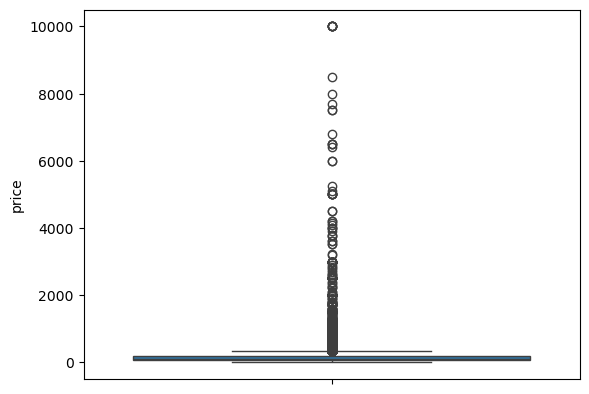

In [22]:
sns.boxplot(data = df, y = "price")
plt.show()

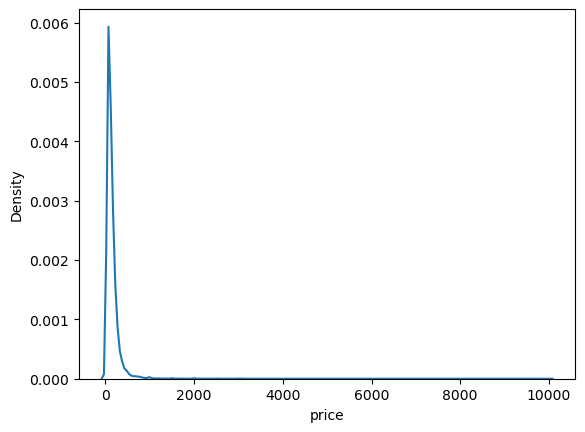

In [23]:
sns.kdeplot(data = df, x = "price")
plt.show()

In [24]:
df[df["price"] > 5000].shape

(20, 11)

In [25]:
df = df[df["price"] <= 5000]

In [26]:
df[df["price"] == 0].shape

(11, 11)

In [27]:
df.drop(df[df["price"] == 0].index, inplace=True)

In [28]:
df["price_log"] = np.log1p(df["price"])

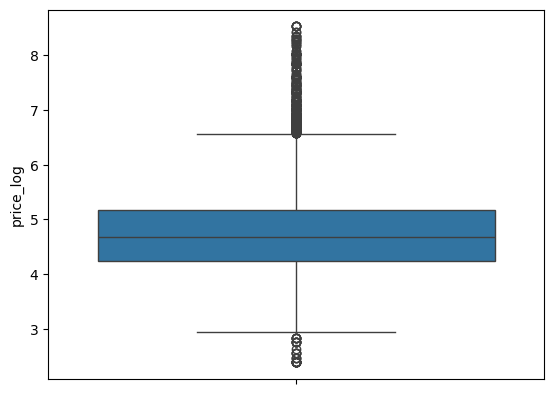

In [29]:
sns.boxplot(data=df, y="price_log")
plt.show()

In [30]:
df.drop("price", axis=1, inplace=True)

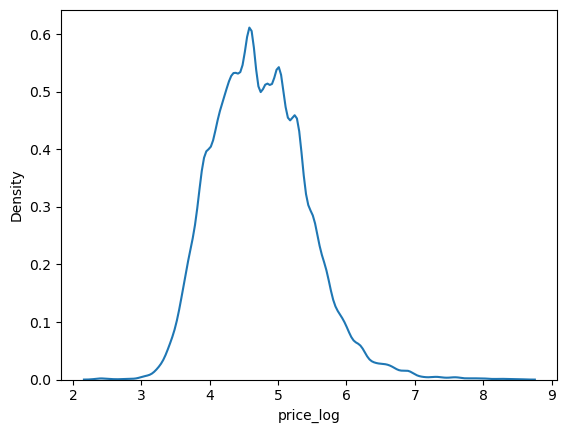

In [31]:
sns.kdeplot(data = df, x = "price_log")
plt.show()

Other numeric columns (minimum_nights, number_of_reviews, reviews_per_month, 
calculated_host_listings_count, availability_365, days_since_last_review) were checked for 
skewness via KDE plots, similar to price. Since Airbnb data typically follows a "most listings 
low, a few extremely high" pattern, log1p was applied to all 6 of these columns as well.

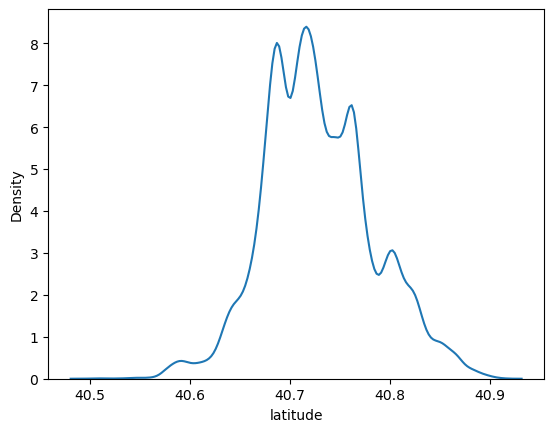

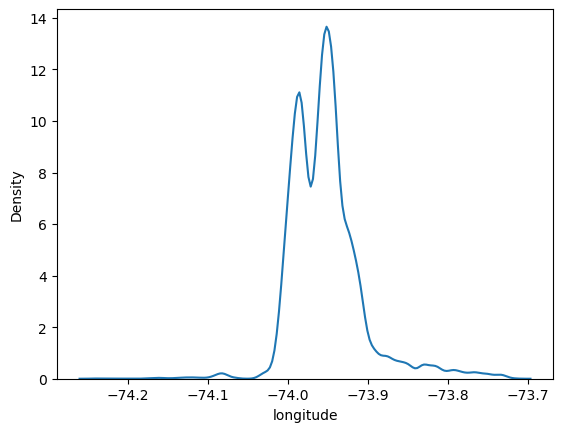

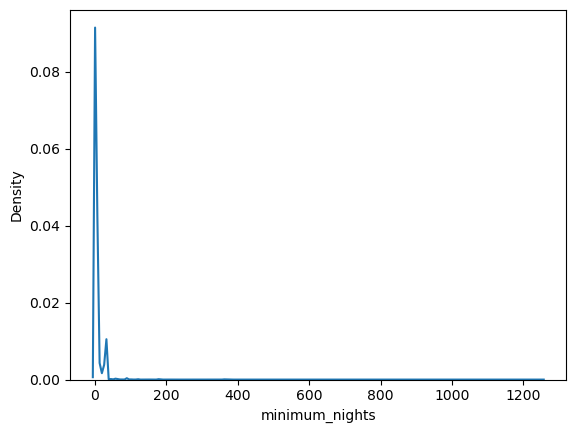

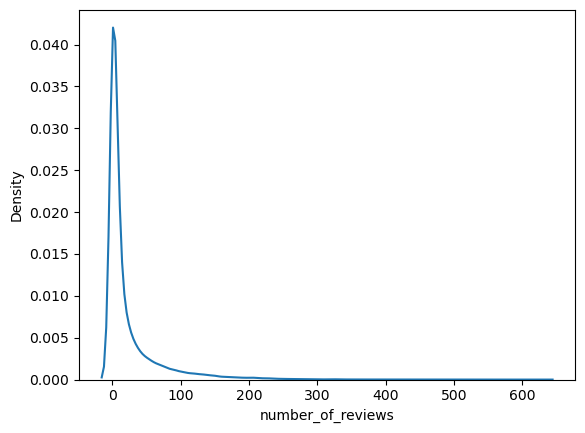

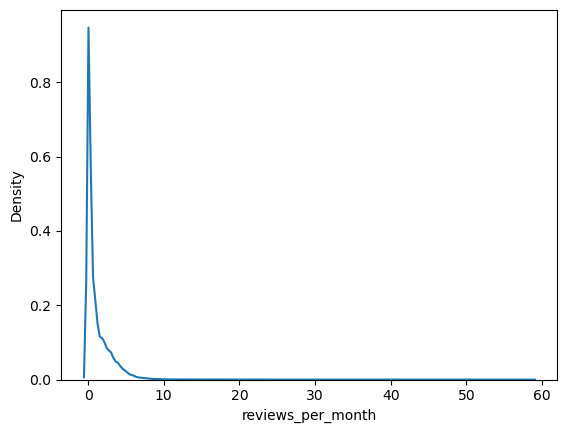

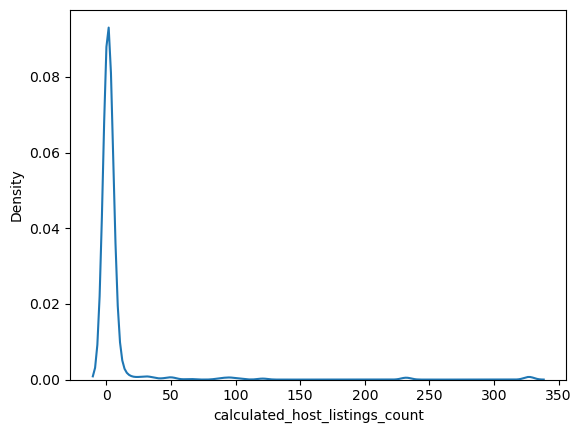

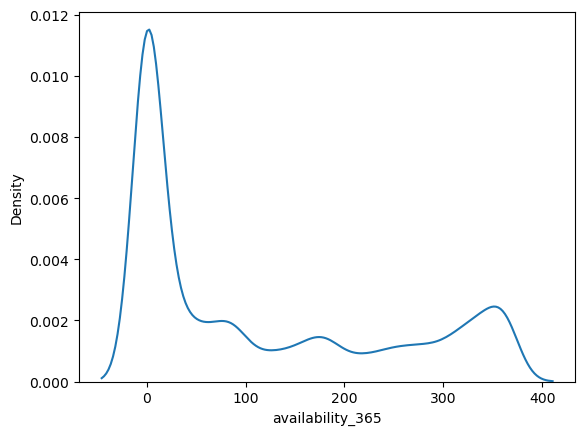

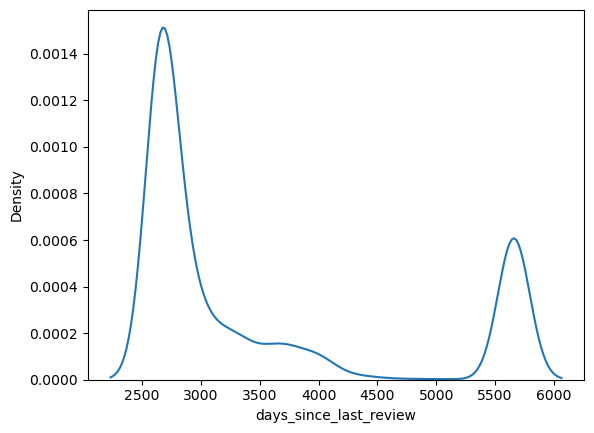

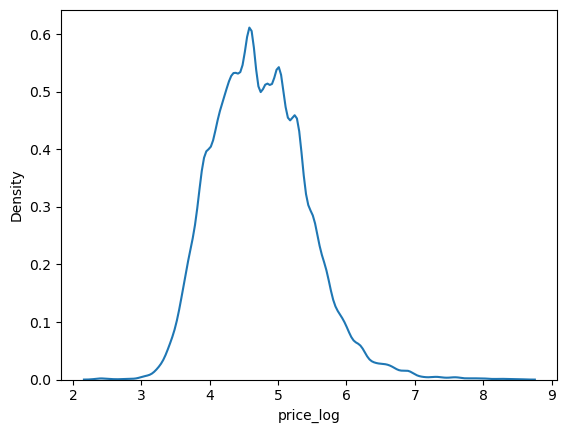

In [32]:
numeric_cols = df.select_dtypes(include=np.number).columns

for i in numeric_cols:
    sns.kdeplot(data=df, x=df[i])
    plt.show()

In [33]:
columns_feature = ["minimum_nights","number_of_reviews","reviews_per_month","calculated_host_listings_count","availability_365","days_since_last_review"]

for i in columns_feature:
    df[i] = np.log1p(df[i])

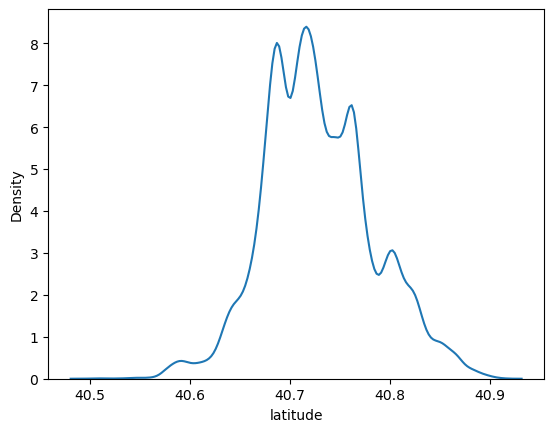

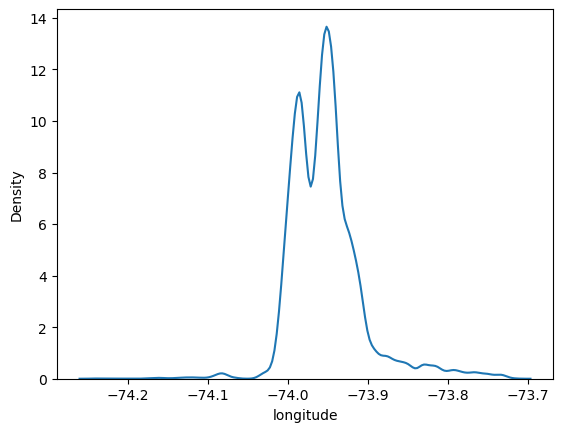

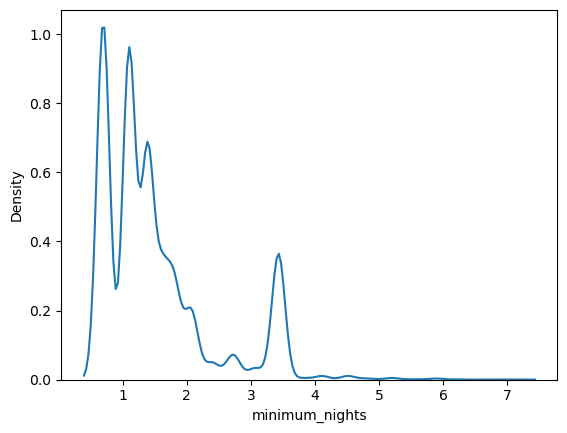

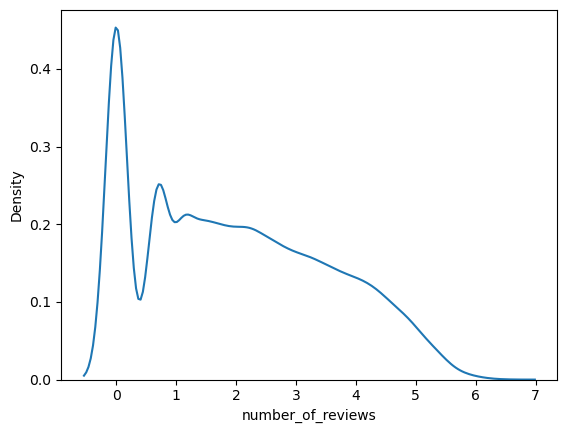

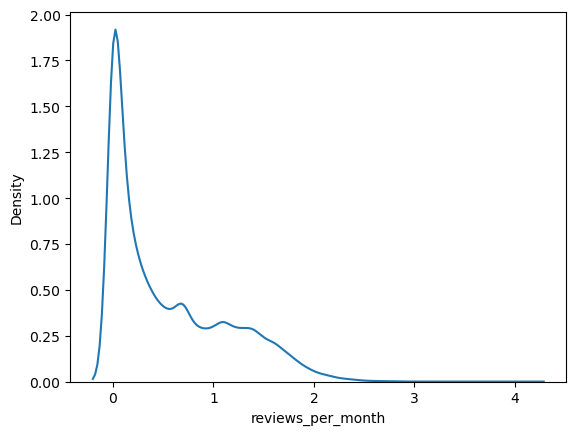

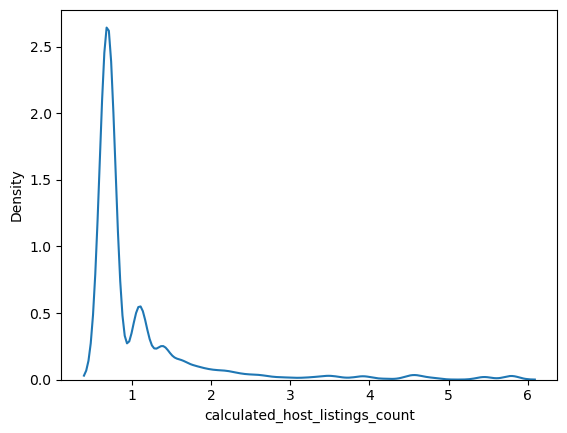

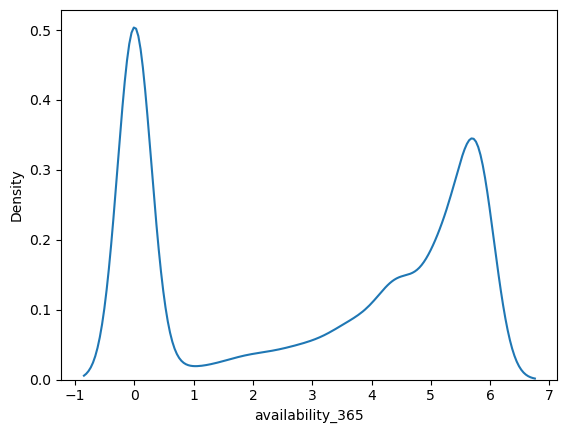

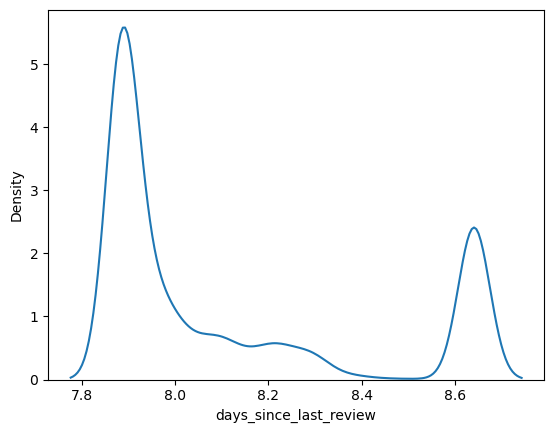

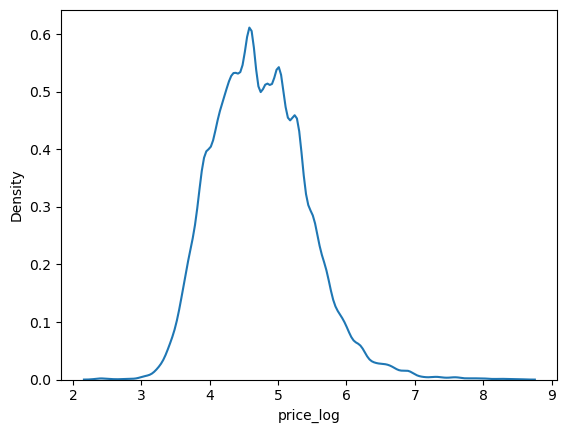

In [34]:
numeric_cols = df.select_dtypes(include=np.number).columns

for i in numeric_cols:
    sns.kdeplot(data=df, x=df[i])
    plt.show()

The distribution of categorical variables (neighbourhood_group, room_type), summary statistics 
(describe()), and correlation between numeric columns (heatmap) were examined. This step helps 
both to better understand the data and to spot anomalies before modeling.

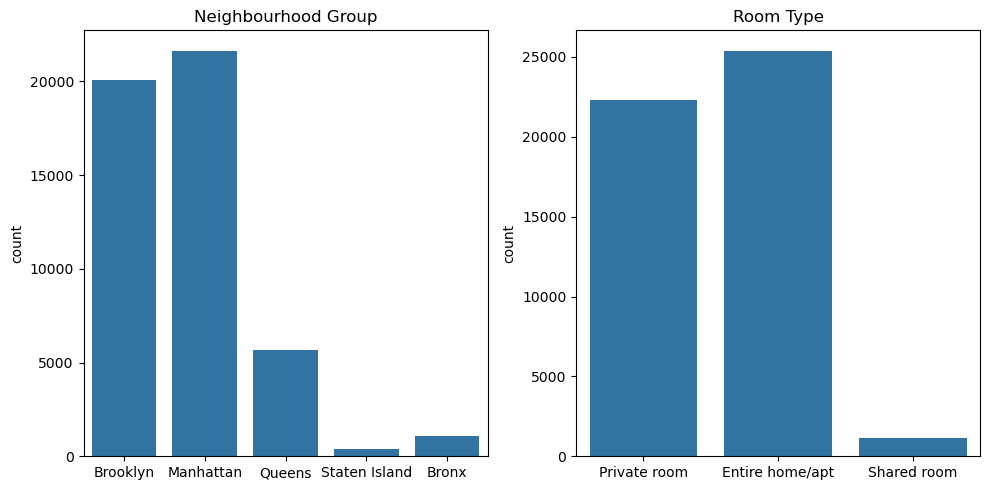

In [35]:
plt.figure(figsize = (10,5))

plt.subplot(1,2,1)
sns.countplot(data = df , x = "neighbourhood_group")
plt.xlabel("")
plt.title("Neighbourhood Group")

plt.subplot(1,2,2)
sns.countplot(data = df, x = "room_type")
plt.xlabel("")
plt.title("Room Type")

plt.tight_layout()
plt.show()

In [36]:
df.describe()

,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review,price_log
count,48864.000000,48864.000000,48864.000000,48864.000000,48864.000000,48864.000000,48864.000000,48864.000000,48864.000000
mean,40.728950,-73.952166,1.499581,1.991195,0.542755,1.087114,2.993620,8.106695,4.736236
std,0.054538,0.046162,0.869284,1.564139,0.577740,0.858770,2.462393,0.294928,0.686698
min,40.499790,-74.244420,0.693147,0.000000,0.000000,0.693147,0.000000,7.877397,2.397895
25%,40.690090,-73.983070,0.693147,0.693147,0.039221,0.693147,0.000000,7.884577,4.248495
50%,40.723080,-73.955680,1.386294,1.791759,0.314811,0.693147,3.828641,7.945555,4.672829
75%,40.763112,-73.936280,1.791759,3.218876,0.947789,1.098612,5.429346,8.252251,5.170484
max,40.913060,-73.712990,7.131699,6.445720,4.085976,5.793014,5.902633,8.641356,8.517393


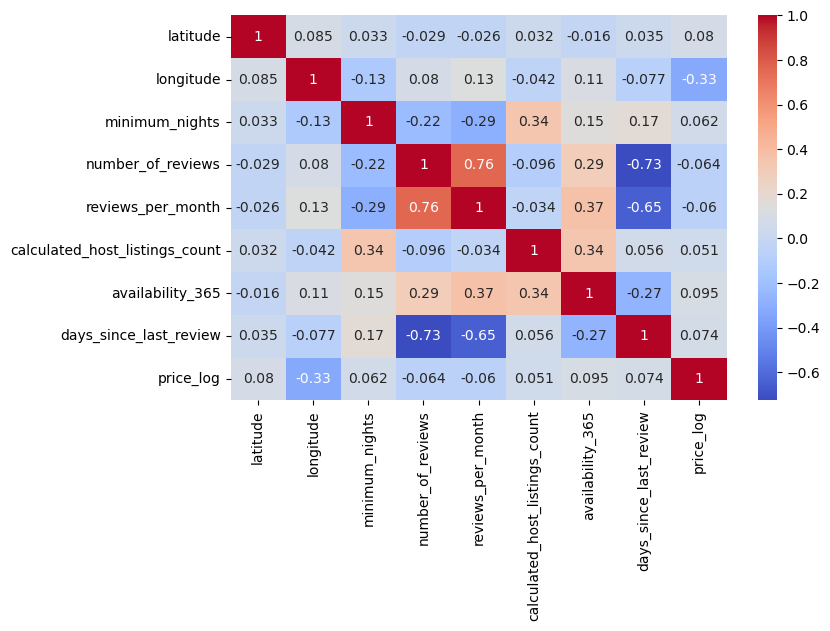

In [37]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot = True, cmap = "coolwarm")
plt.show()

In the first attempt, categorical columns were one-hot encoded via ColumnTransformer, then 
StandardScaler was applied to all columns — including the one-hot encoded 0/1 columns. The 
silhouette score for k=2 (0.62) came out abnormally high compared to every other k value 
(~0.15-0.24) — a suspicious result.

Root cause analysis (inspecting cluster_centers_): the neighbourhood_group_Staten Island 
column showed a z-score difference of 11.6 between clusters — an extreme value. Reason: Staten 
Island is a very rare category in the dataset (0.7%), so StandardScaler computes a tiny standard 
deviation for this column, which blows up the z-score for Staten Island rows. As a result, K-means 
wasn't producing a meaningful segmentation — it was simply splitting on "Staten Island or not".

Lesson: Applying StandardScaler to one-hot encoded (0/1) columns — especially rare categories — 
can distort distance calculations. The correct approach is to scale only continuous numeric columns 
and leave one-hot columns as 0/1.

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(df, test_size=0.3, random_state=15)

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [40]:
categorical_cols = ["neighbourhood_group","room_type"]

preprocessor = ColumnTransformer(
    [("feature",OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)], remainder="passthrough"
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [41]:
encoded_cols = preprocessor.get_feature_names_out()

X_train = pd.DataFrame(X_train, columns = encoded_cols)
X_test = pd.DataFrame(X_test, columns = encoded_cols)

In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
from sklearn.cluster import KMeans

In [44]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k ,init = "k-means++", random_state=15)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [45]:
wcss

[513059.99999996147,
 474062.20774366066,
 374407.22621704964,
 343522.3555231046,
 314173.0278307568,
 286816.3581454089,
 255522.76311819314,
 265470.92502605205,
 227710.88244836227,
 218438.63743539466]

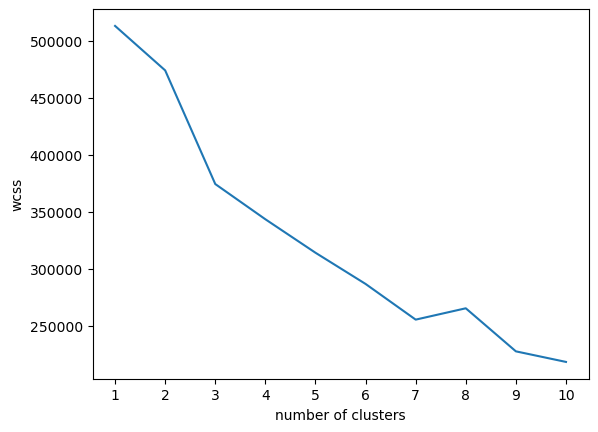

In [46]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylabel("wcss")
plt.show()

In [47]:
from sklearn.metrics import silhouette_score

In [48]:
silhoutte_scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters = k ,init = "k-means++", random_state=15)
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhoutte_scores.append(score)

In [49]:
silhoutte_scores

[0.6247157010438235,
 0.23254440701107787,
 0.20792751692968822,
 0.20606110939025138,
 0.21149795683486128,
 0.2253606938442165,
 0.1963653119799748,
 0.20564792810370117,
 0.2057053205962711]

In [50]:
kmeans = KMeans(n_clusters=2, random_state=15)
kmeans.fit(X_train_scaled)
score = silhouette_score(X_train_scaled,kmeans.labels_)
print(score)

0.6247157010438235


In [51]:
from sklearn.decomposition import PCA

In [52]:
pca = PCA(n_components=2)

In [53]:
X_pca = pca.fit_transform(X_train_scaled)

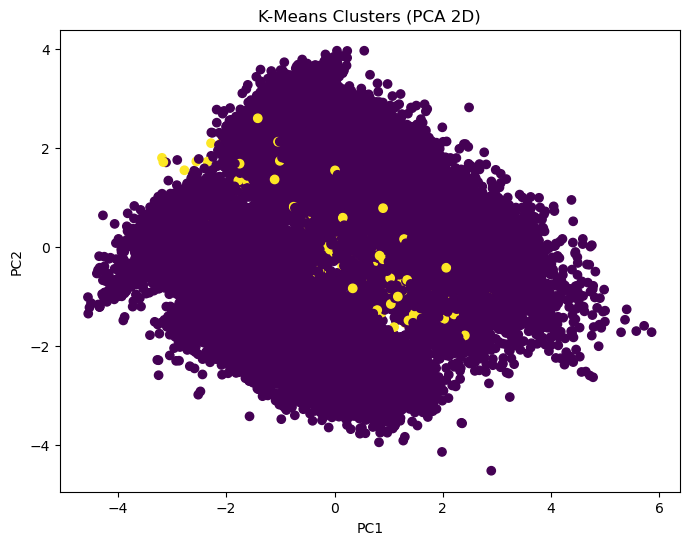

In [54]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans.labels_, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (PCA 2D)")
plt.show()

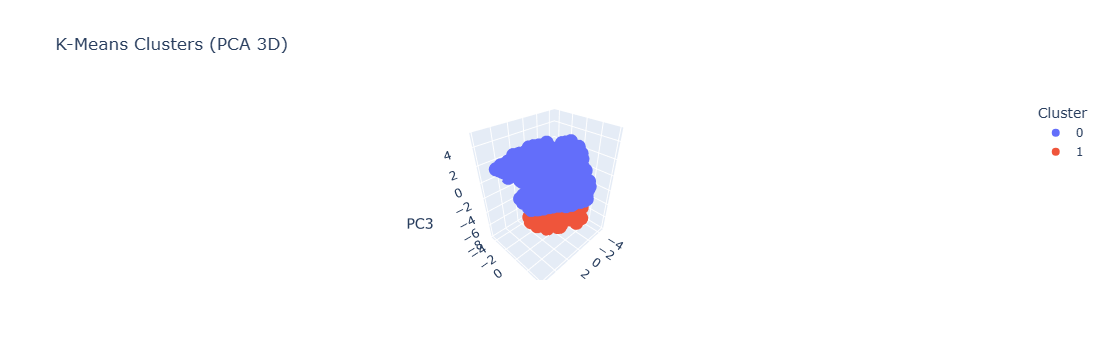

In [55]:
import plotly.express as px

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_train_scaled)

fig = px.scatter_3d(
    x=X_pca_3d[:, 0],
    y=X_pca_3d[:, 1],
    z=X_pca_3d[:, 2],
    color=kmeans.labels_.astype(str),
    labels={"x": "PC1", "y": "PC2", "z": "PC3", "color": "Cluster"},
    title="K-Means Clusters (PCA 3D)"
)
fig.show()

In [56]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=X_train.columns)
centers

,feature__neighbourhood_group_Brooklyn,feature__neighbourhood_group_Manhattan,feature__neighbourhood_group_Queens,feature__neighbourhood_group_Staten Island,feature__room_type_Private room,feature__room_type_Shared room,remainder__latitude,remainder__longitude,remainder__minimum_nights,remainder__number_of_reviews,remainder__reviews_per_month,remainder__calculated_host_listings_count,remainder__availability_365,remainder__days_since_last_review,remainder__price_log
0,0.006189,0.006619,0.002696,-0.086152,-0.000704,-0.00045,0.016291,0.024982,0.002239,-0.002295,-0.002926,0.000067,-0.004192,0.002248,0.004384
1,-0.833886,-0.891741,-0.363192,11.607332,0.094891,0.06060,-2.194903,-3.365780,-0.301674,0.309160,0.394280,-0.009005,0.564745,-0.302807,-0.590636


The ColumnTransformer was rebuilt so that OneHotEncoder applies only to categorical columns 
(neighbourhood_group, room_type) and StandardScaler applies only to continuous numeric columns.

With this fix, WCSS (Elbow Method) and Silhouette Score were recomputed:
- Automatic elbow detection via KneeLocator: k=4
- Silhouette scores are now in a reasonable, tight range (~0.16-0.21), and the earlier abnormal 
  k=2 spike disappeared

Combining both methods, k=4 was chosen for the final model.

In [57]:
X_train, X_test = train_test_split(df, test_size=0.3, random_state=15)

In [58]:
numeric_cols = ["latitude", "longitude", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count",
                 "availability_365", "days_since_last_review", "price_log"]

In [59]:
categorical_cols = ["neighbourhood_group", "room_type"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numeric_cols)
])

In [60]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [61]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k ,init = "k-means++", random_state=15)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [62]:
wcss

[337568.4801777568,
 270391.543119563,
 234360.9729854312,
 213937.98660125604,
 197575.8888008318,
 184503.16668062087,
 171605.48465481354,
 165688.94788114185,
 154781.3690286859,
 150369.12159678675]

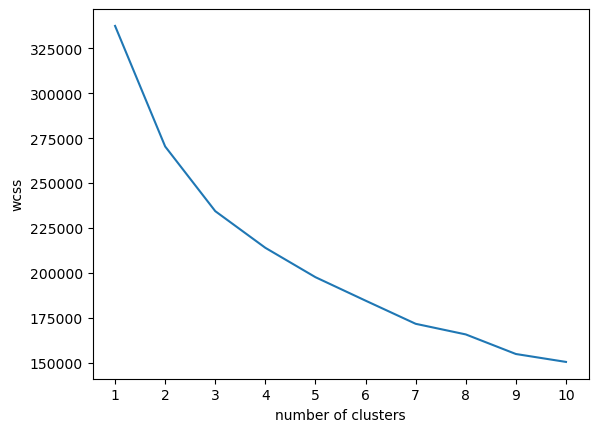

In [63]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylabel("wcss")
plt.show()

In [64]:
from kneed import KneeLocator

In [65]:
kl = KneeLocator(range(1,11), wcss, curve = "convex", direction = "decreasing")

In [66]:
kl.elbow

np.int64(3)

In [67]:
silhoutte_scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters = k ,init = "k-means++", random_state=15)
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhoutte_scores.append(score)

In [68]:
silhoutte_scores

[0.19281517675040147,
 0.2131656427194894,
 0.1678887908200903,
 0.15906680793766467,
 0.16980513123844287,
 0.1619782503791708,
 0.16104424906650433,
 0.17073536996508168,
 0.15921795678026918]

The K-means model was trained with k=4, and cluster labels were assigned to both the train and 
test sets (using predict for test, not fit, to avoid leakage). Then each cluster's average 
features (groupby("cluster").mean()) and categorical distributions (value_counts(normalize=True)) 
were extracted to interpret the clusters.

In [69]:
kmeans = KMeans(n_clusters=4, init="k-means++", random_state=15)
kmeans.fit(X_train_scaled)
X_train["cluster"] = kmeans.labels_

In [70]:
X_test["cluster"] = kmeans.predict(X_test_scaled)

In [71]:
cluster_profile_numeric = X_train.groupby("cluster").mean(numeric_only=True)
print(cluster_profile_numeric)

print(X_train.groupby("cluster")["neighbourhood_group"].value_counts(normalize=True))
print(X_train.groupby("cluster")["room_type"].value_counts(normalize=True))

          latitude  longitude  minimum_nights  number_of_reviews  \
cluster                                                            
0        40.727739 -73.961348        1.484575           1.707736   
1        40.744361 -73.971437        3.277909           0.904724   
2        40.727470 -73.938287        1.187869           3.442356   
3        40.730574 -73.953402        1.545658           0.038385   

         reviews_per_month  calculated_host_listings_count  availability_365  \
cluster                                                                        
0                 0.283883                        0.801023          1.365026   
1                 0.189940                        3.647151          5.414535   
2                 1.132661                        1.038877          4.637358   
3                 0.001226                        0.851330          2.107791   

         days_since_last_review  price_log  
cluster                                     
0                   

In [72]:
X_train["cluster"].value_counts()

cluster
0    12843
2    12772
3     6330
1     2259
Name: count, dtype: int64

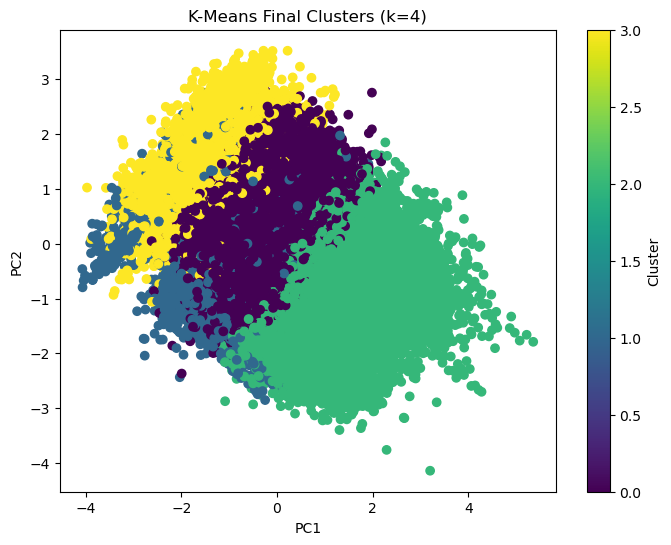

In [73]:
X_pca_final = pca.transform(X_train_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca_final[:,0], X_pca_final[:,1], c=X_train["cluster"], cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Final Clusters (k=4)")
plt.colorbar(label="Cluster")
plt.show()

In [74]:
import plotly.express as px

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_train_scaled)

fig = px.scatter_3d(
    x=X_pca_3d[:, 0],
    y=X_pca_3d[:, 1],
    z=X_pca_3d[:, 2],
    color=kmeans.labels_.astype(str),
    labels={"x": "PC1", "y": "PC2", "z": "PC3", "color": "Cluster"},
    title="K-Means Clusters (PCA 3D)"
)
fig.show()

In [75]:
cluster_profile_test = X_test.groupby("cluster").mean(numeric_only=True)
print(cluster_profile_test)

print(X_test.groupby("cluster")["neighbourhood_group"].value_counts(normalize=True))
print(X_test.groupby("cluster")["room_type"].value_counts(normalize=True))

          latitude  longitude  minimum_nights  number_of_reviews  \
cluster                                                            
0        40.727035 -73.962416        1.500828           1.711598   
1        40.742815 -73.969594        3.276925           0.921286   
2        40.725860 -73.939532        1.182634           3.423723   
3        40.730398 -73.953901        1.483657           0.036020   

         reviews_per_month  calculated_host_listings_count  availability_365  \
cluster                                                                        
0                 0.287616                        0.806080          1.428431   
1                 0.188987                        3.700717          5.424746   
2                 1.134209                        1.045890          4.640529   
3                 0.001115                        0.855611          2.051681   

         days_since_last_review  price_log  
cluster                                     
0                   

(Note: values are log1p-transformed, so they should be read as relative comparisons between 
clusters rather than absolute numbers.)

Cluster 0 — "Mid-tier, low availability" (10,305 listings, ~37.5% of train)
- Mid-range price
- Lowest availability_365 → rarely vacant throughout the year
- Manhattan (46.5%) and Brooklyn (45.8%) nearly equal
- Entire home/apt dominant (55.6%)

Cluster 1 — "Premium / Professional host" (2,382 listings, ~6.6% of train, smallest cluster)
- Highest price_log
- Highest calculated_host_listings_count → hosts managing multiple listings 
  (property-management-style accounts)
- Highest availability_365 → largely available year-round
- Fewest reviews — likely newer or less review-focused, premium/institutional segment
- Manhattan dominant (77.7%), Entire home/apt dominant (71.8%)

Cluster 2 — "Passive / dormant listings" (6,201 listings, ~37.3% of train)
- number_of_reviews close to zero
- Highest days_since_last_review → longest time since the last review
- Location/price distribution similar to Cluster 0; the defining trait here is lack of activity

Cluster 3 — "Popular / active listings" (15,316 listings, ~18.5% of train, largest cluster)
- Highest number_of_reviews and reviews_per_month
- Lowest days_since_last_review → most recent reviews
- Brooklyn-leaning (42%), higher Queens share than other clusters (16%)
- The platform's "healthy", actively-running core segment

Overall pattern: Contrary to expectations, the clusters separate more along an activity / 
business-model axis than a purely geographic one. Cluster 1 and Cluster 2 are near-opposites 
(expensive-professional-low-reviews vs. dormant-abandoned), Cluster 3 is the platform's active 
core, and Cluster 0 sits in between.

In [76]:
print(X_train["cluster"].value_counts(normalize=True))
print(X_test["cluster"].value_counts(normalize=True))

cluster
0    0.375482
2    0.373407
3    0.185066
1    0.066045
Name: proportion, dtype: float64
cluster
0    0.374829
2    0.373738
3    0.188540
1    0.062892
Name: proportion, dtype: float64


We tested the model's reliability from two angles:

a) Train/Test consistency: The same cluster profiling was computed on the test set and compared 
to train. Cluster proportions were nearly identical between train and test (e.g. Cluster 0: 
train 37.5% vs test 37.5%, Cluster 3: train 18.5% vs test 18.9%) — a strong sign the model 
generalizes rather than overfitting.

b) Stability check: The same k=4 model was trained multiple times with different random_state 
values, and the resulting silhouette scores were compared. Scores stayed within a narrow band 
(0.15-0.18), with no large jumps (e.g. 0.10 vs 0.30) — the model produces reasonably stable 
results regardless of the random initialization.

In [77]:
for rs in [0, 15, 42, 100, 2024]:
    km = KMeans(n_clusters=4, init="k-means++", random_state=rs)
    km.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, km.labels_)
    print(f"random_state={rs} -> silhouette={score:.4f}")

random_state=0 -> silhouette=0.1508
random_state=15 -> silhouette=0.1679
random_state=42 -> silhouette=0.1775
random_state=100 -> silhouette=0.1679
random_state=2024 -> silhouette=0.1775


After identifying and fixing a preprocessing bug (accidentally scaling one-hot columns), NYC 
Airbnb listings were segmented via K-Means into k=4 clusters that are meaningful, consistent 
between train and test, and stable across different random_state values:

1. Mid-tier, low availability — rarely vacant, Manhattan/Brooklyn mix
2. Premium / Professional host — expensive, multi-listing institutional hosts, Manhattan-heavy
3. Passive / dormant listings — almost no reviews, inactive for a long time
4. Popular / active listings — most-reviewed, fresh and dynamic, Brooklyn-leaning, the platform's 
   largest and "healthiest" segment

Possible use cases:
- Pricing strategy: Cluster 1 (premium) and Cluster 3 (popular) could warrant different 
  pricing/marketing approaches
- Host outreach: Cluster 2 (dormant) hosts could be targeted with activation/review-boosting 
  campaigns
- Market analysis: Cluster 1's concentration of institutional/professional hosts in Manhattan 
  can be used to study the platform's professionalization trend

Possible next steps: Evaluate alternative k values (e.g. k=5, k=6) to see if they yield more 
business-useful segmentations, compare against a density-based algorithm like DBSCAN, or build 
a price-prediction (regression) model conditioned on cluster membership.